# Analyzing customer drop-off points to optimize conversion

## Project Overview
This project analyzes e-commerce user behavior to identify critical drop-off points in the customer journey. By processing data across multiple channels—including user activity, subscription plans, and sales orders—I have visualized the conversion funnel and identified key areas for retention improvement.

<b>Key Insights:<b>

1. Identified the primary bottleneck in the conversion process.

2. Analyzed city-wise performance to highlight regional trends.

3. Evaluated revenue contribution by subscription plan.

## 1. Project Setup and Data Importing

In [135]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [136]:
ca = pd.read_csv('cust_activity.csv')
cb = pd.read_csv('cust_bio.csv')
cs = pd.read_csv('cust_sub.csv')
sp = pd.read_csv('sp.csv')
orders = pd.read_csv('orders.csv')

In [137]:
print(ca.shape)
print(cb.shape)
print(cs.shape)
print(sp.shape)
print(orders.shape)

(7500, 3)
(478, 3)
(51, 3)
(6, 5)
(127, 4)


In [138]:
tables = [ca, cb, cs, sp, orders]
for i in tables:
    print(i.columns)

Index(['Cust_ID', 'Activity', 'Date'], dtype='object')
Index(['Cust_ID', 'City', 'Age'], dtype='object')
Index(['Cust_ID', 'Plan_Var_ID', 'Purchase_Date'], dtype='object')
Index(['Plan_Var_ID', 'Plan_ID', 'Plan_name', 'Price', 'Duration'], dtype='object')
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')


## 2. Data Quality Assessment

In [139]:
for i, name in zip(tables, ['Activity', 'Bio', 'Subscription', 'Plans', 'Orders']):
    print(f"--- Checking {name} ---")
    print(f"Duplicates: {i.duplicated().sum()}")
    print(f"Missing Values:\n{i.isnull().sum()}\n")

--- Checking Activity ---
Duplicates: 0
Missing Values:
Cust_ID     0
Activity    0
Date        0
dtype: int64

--- Checking Bio ---
Duplicates: 0
Missing Values:
Cust_ID    0
City       0
Age        0
dtype: int64

--- Checking Subscription ---
Duplicates: 0
Missing Values:
Cust_ID          0
Plan_Var_ID      0
Purchase_Date    0
dtype: int64

--- Checking Plans ---
Duplicates: 0
Missing Values:
Plan_Var_ID    0
Plan_ID        0
Plan_name      0
Price          0
Duration       0
dtype: int64

--- Checking Orders ---
Duplicates: 0
Missing Values:
Order_id        0
Cust_ID         0
Amount          0
Payment_mode    0
dtype: int64



## 3. Exploratory Data Analysis (EDA)

### 3.1 Customer Distribution by City

In [140]:
q1 =  cb['City'].value_counts().reset_index()
q1

,City,count
0,Chennai,109
1,Delhi,106
2,Kolkata,94
3,Noida,92
4,Mumbai,77


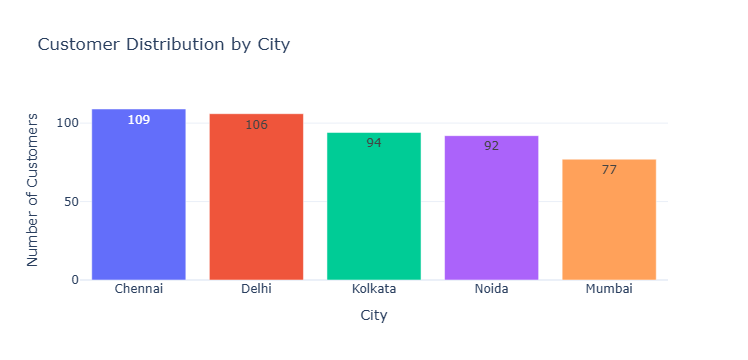

In [141]:
fig = px.bar(
    data_frame=q1, 
    x='City', 
    y='count', 
    text='count', 
    color='City', 
    title='Customer Distribution by City',
    template='plotly_white')

fig.update_layout(
    xaxis_title="City",
    yaxis_title="Number of Customers",
    showlegend=False)

fig.show()

### 3.2 Age-Based Customer Segmentation

In [142]:
cb['Age'].describe()

count    478.000000
mean      28.740586
std        5.376756
min       20.000000
25%       24.000000
50%       29.000000
75%       34.000000
max       37.000000
Name: Age, dtype: float64

In [143]:
# Binning- Conversion of continuous data into categorical data
cb['Age_Range'] = pd.cut(cb['Age'],bins = [20,23,26,29,32,35,38])
                        

In [144]:
q2 = cb['Age_Range'].value_counts().reset_index()   
q2['Age_Range'] = q2['Age_Range'].astype(str)
q2

,Age_Range,count
0,"(20, 23]",88
1,"(32, 35]",85
2,"(26, 29]",78
3,"(29, 32]",74
4,"(23, 26]",67
5,"(35, 38]",62


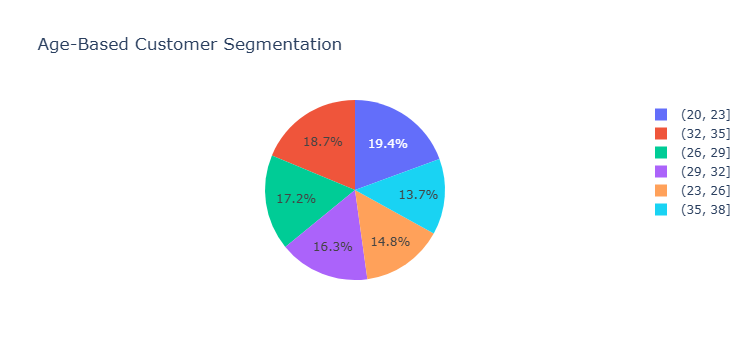

In [145]:
fig = px.pie(data_frame=q2, 
             names='Age_Range', 
             values='count', 
             title='Age-Based Customer Segmentation',
             template='plotly_white')

fig.show()

### 3.3 Platform Activity Volume

In [146]:
q3 = ca['Activity'].value_counts().reset_index()
q3

,Activity,count
0,Browse,6548
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


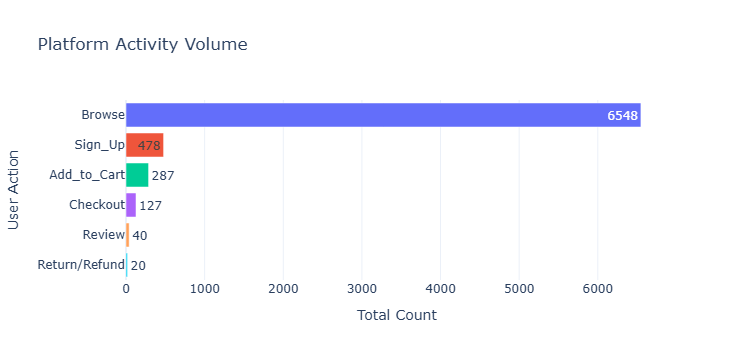

In [147]:
fig = px.bar(
    data_frame=q3, 
    y='Activity',  
    x='count',
    text='count', 
    color='Activity', 
    orientation='h', 
    title='Platform Activity Volume',
    template='plotly_white')

fig.update_layout(
    xaxis_title="Total Count",
    yaxis_title="User Action",
    showlegend=False)

fig.show()

### 3.4 Monthly Order Trends

In [148]:
print(orders.columns)
print(ca.columns)

Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')
Index(['Cust_ID', 'Activity', 'Date'], dtype='object')


In [149]:
ca_cout = ca[ca['Activity']=='Checkout']

In [150]:
ca_orders_count = pd.merge(orders,ca_cout,on='Cust_ID',how='inner')
ca_orders_count.shape

(127, 6)

In [151]:
ca_orders_count.head()

,Order_id,Cust_ID,Amount,Payment_mode,Activity,Date
0,ORD_71,CUS_545,2123.19,UPI,Checkout,2024-04-26
1,ORD_72,CUS_622,2788.02,Net Banking,Checkout,2024-02-01
2,ORD_73,CUS_418,3071.63,Credit_Card,Checkout,2024-07-22
3,ORD_74,CUS_360,5736.31,COD,Checkout,2025-05-24
4,ORD_75,CUS_714,1592.53,Debit Card,Checkout,2024-06-19


In [152]:
ca_orders_count['Date'] = pd.to_datetime(ca_orders_count['Date'])

In [153]:
ca_orders_count['Month'] = ca_orders_count['Date'].dt.month

In [154]:
q4 = ca_orders_count.groupby('Month')['Amount'].sum().round(2).reset_index()

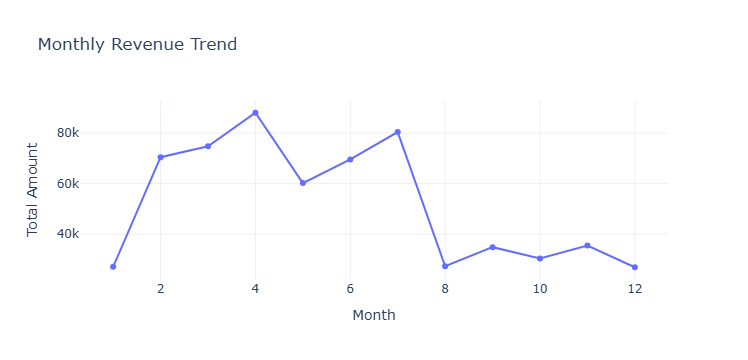

In [155]:
fig = px.line(data_frame=q4, 
              x='Month', 
              y='Amount',
              markers=True,
              title='Monthly Revenue Trend',
              template='plotly_white')

fig.update_layout(xaxis_title="Month", 
                  yaxis_title="Total Amount")

fig.show()

### 3.5 Subscription Revenue Performance

In [156]:
print(sp.columns)
print(cs.columns)
print(cs.shape)

Index(['Plan_Var_ID', 'Plan_ID', 'Plan_name', 'Price', 'Duration'], dtype='object')
Index(['Cust_ID', 'Plan_Var_ID', 'Purchase_Date'], dtype='object')
(51, 3)


In [157]:
cs['Cust_ID'].nunique()

51

In [158]:
cs_sp = pd.merge(cs,sp,on='Plan_Var_ID',how='inner')
cs_sp.head()  

,Cust_ID,Plan_Var_ID,Purchase_Date,Plan_ID,Plan_name,Price,Duration
0,CUS_626,P1_1Y,2025-05-15,P1,Silver,1200.0,1 Year
1,CUS_723,P1_1Y,2024-07-23,P1,Silver,1200.0,1 Year
2,CUS_575,P1_1Y,2024-11-14,P1,Silver,1200.0,1 Year
3,CUS_232,P2_6M,2025-04-19,P2,Gold,1440.0,6 Months
4,CUS_346,P2_1Y,2024-01-31,P2,Gold,2400.0,1 Year


In [159]:
q5 = cs_sp.groupby(['Plan_name', 'Duration'])['Price'].sum().reset_index()
q5

,Plan_name,Duration,Price
0,Diamond,1 Year,28800.0
1,Diamond,6 Months,25920.0
2,Gold,1 Year,24000.0
3,Gold,6 Months,7200.0
4,Silver,1 Year,16800.0
5,Silver,6 Months,5040.0


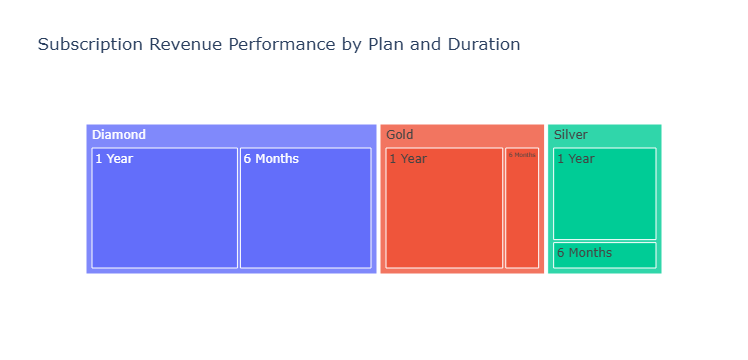

In [160]:
fig = px.treemap(q5, 
                 path=['Plan_name', 'Duration'], 
                 values='Price',
                 title='Subscription Revenue Performance by Plan and Duration',
                 template='plotly_white')

fig.show()

### 3.6 Regional Revenue Contribution

In [161]:
print(cb.columns)
print(orders.columns)

Index(['Cust_ID', 'City', 'Age', 'Age_Range'], dtype='object')
Index(['Order_id', 'Cust_ID', 'Amount', 'Payment_mode'], dtype='object')


In [162]:
cb_orders = pd.merge(cb, orders, on='Cust_ID', how='inner')
cb_orders.head()

,Cust_ID,City,Age,Age_Range,Order_id,Amount,Payment_mode
0,CUS_121,Noida,30,"(29.0, 32.0]",ORD_83,3336.69,UPI
1,CUS_127,Delhi,24,"(23.0, 26.0]",ORD_172,6427.90,Credit_Card
2,CUS_129,Mumbai,20,NaN,ORD_97,8653.62,UPI
3,CUS_135,Kolkata,35,"(32.0, 35.0]",ORD_87,2551.37,Credit_Card
4,CUS_139,Noida,34,"(32.0, 35.0]",ORD_127,3290.14,UPI


In [163]:
q6 = cb_orders.groupby('City')['Amount'].sum().reset_index()
q6['Amount'] = q6['Amount'].round(2)
q6_matrix = q6.set_index('City').T
q6_matrix

City,Chennai,Delhi,Kolkata,Mumbai,Noida
Amount,96763.72,147176.17,102185.83,120515.98,158552.95


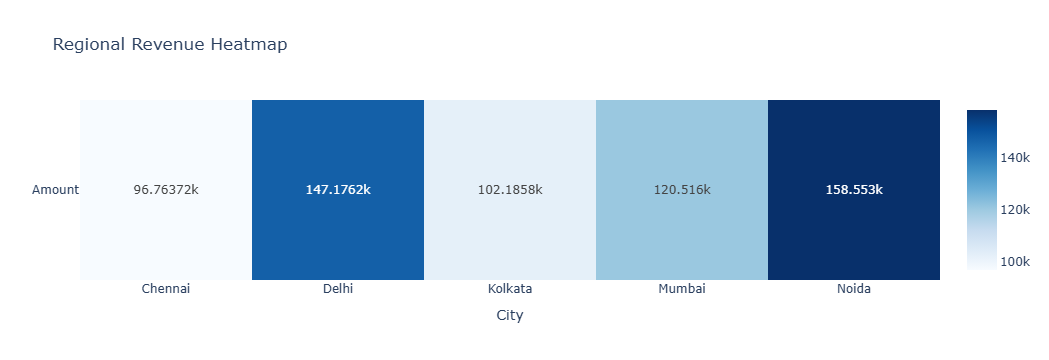

In [164]:
fig = px.imshow(q6_matrix, 
                text_auto=True, 
                aspect="auto", 
                title="Regional Revenue Heatmap",
                color_continuous_scale='Blues')

fig.show()

### 3.7 Payment Method Distribution

In [165]:
q7 = orders['Payment_mode'].value_counts().reset_index()
q7

,Payment_mode,count
0,Net Banking,29
1,Debit Card,27
2,UPI,24
3,Credit_Card,24
4,COD,23


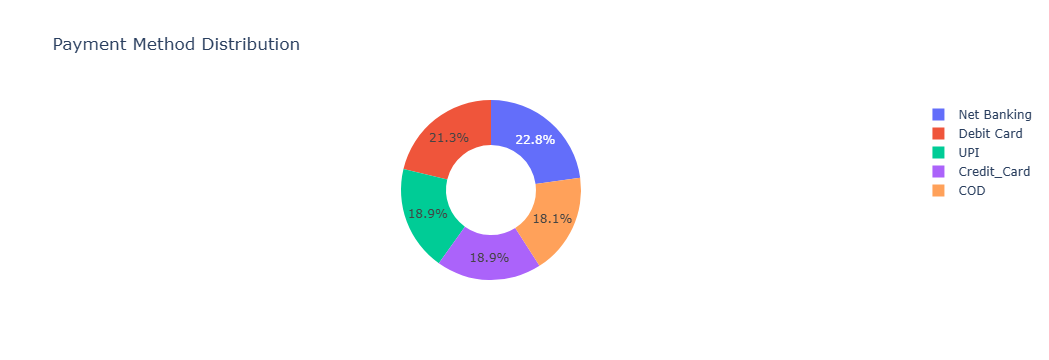

In [166]:
fig = px.pie(data_frame=q7, 
             names='Payment_mode', 
             values='count', 
             hole=0.5,
             title='Payment Method Distribution',
             template='plotly_white')

fig.show()

### 3.8 Payment Amount Distribution

In [167]:
q8 = orders.groupby('Payment_mode')['Amount'].sum().reset_index()
q8

,Payment_mode,Amount
0,COD,115972.27
1,Credit_Card,127611.89
2,Debit Card,133145.11
3,Net Banking,137780.34
4,UPI,110685.04


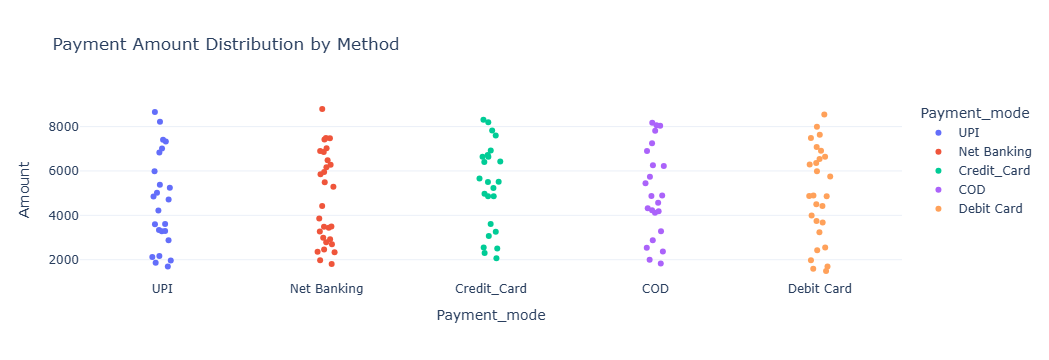

In [168]:
fig = px.strip(data_frame=orders, 
               x='Payment_mode', 
               y='Amount', 
               color='Payment_mode', 
               title='Payment Amount Distribution by Method',
               template='plotly_white')

fig.show()

## 4. Funnel Analysis
Analyzing customer drop-off points to optimize conversion.

### 4.1 Global Conversion Funnel

In [169]:
f1 = ca.groupby(['Cust_ID','Activity'])['Activity'].count().reset_index(name='count')
f1.head()   

,Cust_ID,Activity,count
0,CUS_121,Add_to_Cart,1
1,CUS_121,Browse,8
2,CUS_121,Checkout,1
3,CUS_121,Sign_Up,1
4,CUS_122,Browse,10


In [170]:
funnel = f1['Activity'].value_counts().reset_index()
funnel

,Activity,count
0,Browse,681
1,Sign_Up,478
2,Add_to_Cart,287
3,Checkout,127
4,Review,40
5,Return/Refund,20


In [171]:
funnel['prev_count'] = np.where(funnel['Activity']=='Return/Refund', 
                                funnel['count'].shift(2),
                                funnel['count'].shift(1))
funnel

,Activity,count,prev_count
0,Browse,681,NaN
1,Sign_Up,478,681.0
2,Add_to_Cart,287,478.0
3,Checkout,127,287.0
4,Review,40,127.0
5,Return/Refund,20,127.0


In [172]:
funnel['Percent_Conv'] = round((funnel['count']/funnel['prev_count'])*100,2)
funnel.fillna(0,inplace=True)
funnel

,Activity,count,prev_count,Percent_Conv
0,Browse,681,0.0,0.00
1,Sign_Up,478,681.0,70.19
2,Add_to_Cart,287,478.0,60.04
3,Checkout,127,287.0,44.25
4,Review,40,127.0,31.50
5,Return/Refund,20,127.0,15.75


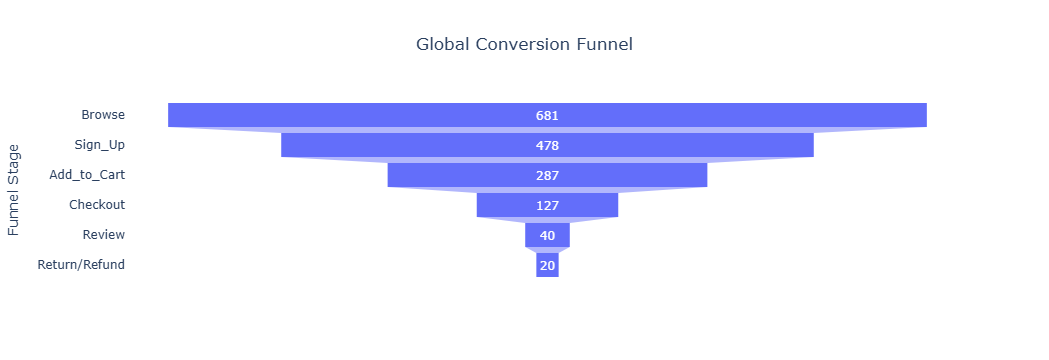

In [173]:
fig = px.funnel(data_frame=funnel, 
                y='Activity', 
                x='count', 
                hover_data=['Percent_Conv'], 
                title='Global Conversion Funnel',
                template='plotly_white')

fig.update_layout(
    title_x=0.5,
    xaxis_title="Number of Customers",
    yaxis_title="Funnel Stage",
    showlegend=False
)


fig.show()

### 4.2 Customer Transition Time Analysis

In [177]:
ca.head() 

,Cust_ID,Activity,Date
0,CUS_121,Sign_Up,2024-04-24
1,CUS_121,Browse,2024-04-27
2,CUS_121,Add_to_Cart,2024-04-27
3,CUS_121,Browse,2024-04-29
4,CUS_121,Browse,2024-04-30


In [178]:
ca['Date'] = pd.to_datetime(ca['Date'])
ca.dtypes

Cust_ID             object
Activity            object
Date        datetime64[ns]
dtype: object

In [179]:
pt1 = pd.pivot_table(data=ca,index=['Cust_ID'],columns=['Activity'],  
                    values='Date',aggfunc='min')
pt1.head()

Activity,Add_to_Cart,Browse,Checkout,Return/Refund,Review,Sign_Up
Cust_ID,,,,,,
CUS_121,2024-04-27,2024-04-27,2024-05-05,NaT,NaT,2024-04-24
CUS_122,NaT,2025-07-12,NaT,NaT,NaT,NaT
CUS_123,NaT,2024-04-14,NaT,NaT,NaT,NaT
CUS_124,2025-01-06,2025-01-06,NaT,NaT,NaT,2025-01-05
CUS_125,NaT,2024-06-17,NaT,NaT,NaT,2024-06-15


In [180]:
# DD = datediff
pt1['Signup_2Browse_DD'] = abs((pt1['Sign_Up'] - pt1['Browse']).dt.days)    
pt1['Browse_2Add2cart_DD'] = (pt1['Add_to_Cart'] - pt1['Browse']).dt.days
pt1['Add2cart_2Checkout_DD'] = (pt1['Checkout'] - pt1['Add_to_Cart']).dt.days
pt1['Checkout_2Review_DD'] = (pt1['Review'] - pt1['Checkout']).dt.days
pt1['Checkout_2RR_DD'] = (pt1['Return/Refund'] - pt1['Checkout']).dt.days  


In [185]:
pt2 = pt1.iloc[:,-5:]
pt2 = pt2.fillna(0)
pt2

Activity,Signup_2Browse_DD,Browse_2Add2cart_DD,Add2cart_2Checkout_DD,Checkout_2Review_DD,Checkout_2RR_DD
Cust_ID,,,,,
CUS_121,3.0,0.0,8.0,0.0,0.0
CUS_122,0.0,0.0,0.0,0.0,0.0
CUS_123,0.0,0.0,0.0,0.0,0.0
CUS_124,1.0,0.0,0.0,0.0,0.0
CUS_125,2.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...
CUS_797,4.0,0.0,0.0,0.0,0.0
CUS_798,3.0,0.0,0.0,0.0,0.0
CUS_799,0.0,0.0,0.0,0.0,0.0


### 4.3 Average Duration Between Funnel Stages

In [186]:
dd_avg = pt2.mean().reset_index()  
dd_avg.columns= ['Act_Stages','Avg_Datediff']   
dd_avg

,Act_Stages,Avg_Datediff
0,Signup_2Browse_DD,1.766520
1,Browse_2Add2cart_DD,0.362702
2,Add2cart_2Checkout_DD,2.690162
3,Checkout_2Review_DD,0.154185
4,Checkout_2RR_DD,0.099853


In [187]:
dd_avg['Avg_Datediff'].values

array([1.76651982, 0.36270191, 2.69016153, 0.15418502, 0.09985316])

In [188]:
avg_dd = [0] + list(dd_avg['Avg_Datediff'].values)
avg_dd

[0,
 np.float64(1.7665198237885462),
 np.float64(0.36270190895741555),
 np.float64(2.6901615271659325),
 np.float64(0.15418502202643172),
 np.float64(0.09985315712187959)]

In [189]:
funnel['Avg_Transition_Days'] = avg_dd
funnel

,Activity,count,prev_count,Percent_Conv,Avg_Transition_Days
0,Browse,681,0.0,0.00,0.000000
1,Sign_Up,478,681.0,70.19,1.766520
2,Add_to_Cart,287,478.0,60.04,0.362702
3,Checkout,127,287.0,44.25,2.690162
4,Review,40,127.0,31.50,0.154185
5,Return/Refund,20,127.0,15.75,0.099853


### 4.4 Automated Funnel Analysis by City

In [190]:
ca_cb = pd.merge(ca, cb, on='Cust_ID')
ca_cb

,Cust_ID,Activity,Date,City,Age,Age_Range
0,CUS_121,Sign_Up,2024-04-24,Noida,30,"(29, 32]"
1,CUS_121,Browse,2024-04-27,Noida,30,"(29, 32]"
2,CUS_121,Add_to_Cart,2024-04-27,Noida,30,"(29, 32]"
3,CUS_121,Browse,2024-04-29,Noida,30,"(29, 32]"
4,CUS_121,Browse,2024-04-30,Noida,30,"(29, 32]"
...,...,...,...,...,...,...
5274,CUS_798,Browse,2025-04-05,Chennai,37,"(35, 38]"
5275,CUS_798,Browse,2025-04-06,Chennai,37,"(35, 38]"
5276,CUS_798,Browse,2025-04-09,Chennai,37,"(35, 38]"
5277,CUS_798,Browse,2025-04-13,Chennai,37,"(35, 38]"


In [197]:
def city_funnel(city):
    funnel = ca_cb[ca_cb['City']==city]['Activity'].value_counts().reset_index()

    funnel['prev_count'] = funnel['prev_count'] = np.where(funnel['Activity']=='Return/Refund', 
                                                           funnel['count'].shift(2), 
                                                           funnel['count'].shift(1))
    funnel['Percent_Conv'] = (funnel['count'] / funnel['prev_count'] * 100).round(2)
    funnel.fillna(0,inplace=True)

    print(f"DATA FOR CITY {city.upper()}")
    print(funnel)

    fig = px.funnel(data_frame=funnel,
                    y='Activity',
                    x='count', 
                    hover_data='Percent_Conv',
                    title=f'FUNNEL ANALYSIS FOR CITY {city.upper()}',
                    template='plotly_white')
    
    fig.show()

DATA FOR CITY DELHI
        Activity  count  prev_count  Percent_Conv
0         Browse    968         0.0          0.00
1        Sign_Up    106       968.0         10.95
2    Add_to_Cart     60       106.0         56.60
3       Checkout     30        60.0         50.00
4         Review      6        30.0         20.00
5  Return/Refund      4        30.0         13.33


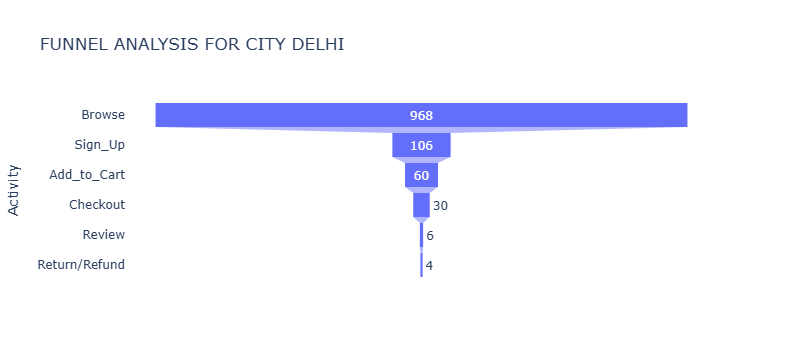

In [198]:
# Calling function for single city
city_funnel('Delhi')

DATA FOR CITY CHENNAI
        Activity  count  prev_count  Percent_Conv
0         Browse   1012         0.0          0.00
1        Sign_Up    109      1012.0         10.77
2    Add_to_Cart     62       109.0         56.88
3       Checkout     18        62.0         29.03
4         Review      9        18.0         50.00
5  Return/Refund      4        18.0         22.22


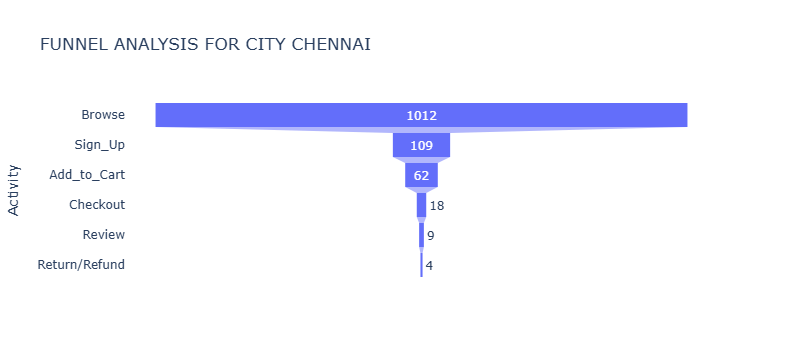

DATA FOR CITY DELHI
        Activity  count  prev_count  Percent_Conv
0         Browse    968         0.0          0.00
1        Sign_Up    106       968.0         10.95
2    Add_to_Cart     60       106.0         56.60
3       Checkout     30        60.0         50.00
4         Review      6        30.0         20.00
5  Return/Refund      4        30.0         13.33


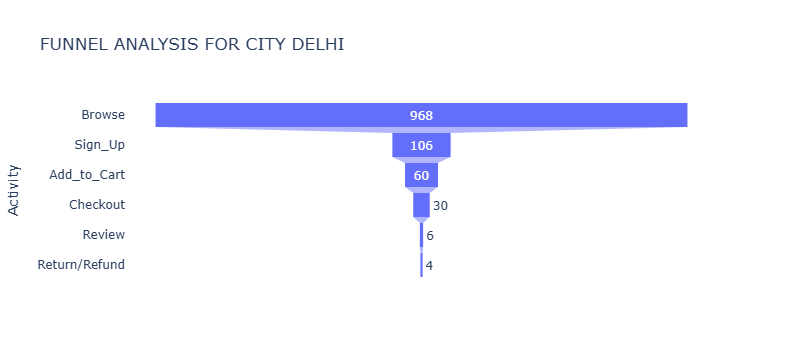

DATA FOR CITY KOLKATA
        Activity  count  prev_count  Percent_Conv
0         Browse    865         0.0          0.00
1        Sign_Up     94       865.0         10.87
2    Add_to_Cart     54        94.0         57.45
3       Checkout     22        54.0         40.74
4         Review      5        22.0         22.73
5  Return/Refund      2        22.0          9.09


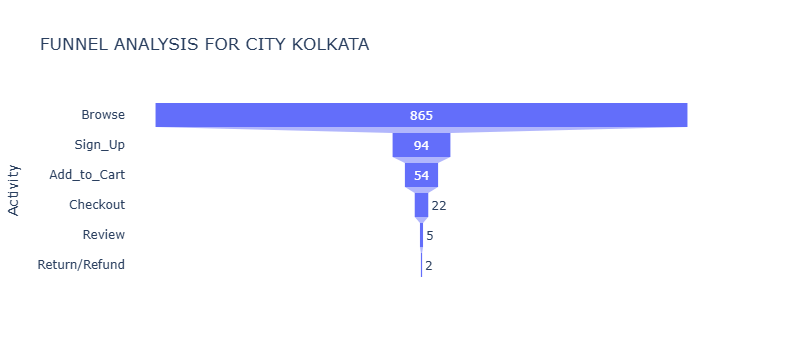

DATA FOR CITY NOIDA
        Activity  count  prev_count  Percent_Conv
0         Browse    797         0.0          0.00
1        Sign_Up     92       797.0         11.54
2    Add_to_Cart     62        92.0         67.39
3       Checkout     34        62.0         54.84
4         Review     10        34.0         29.41
5  Return/Refund      6        34.0         17.65


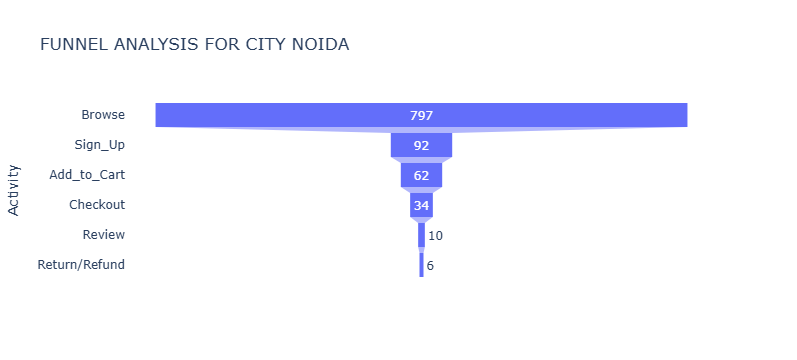

DATA FOR CITY MUMBAI
        Activity  count  prev_count  Percent_Conv
0         Browse    685         0.0          0.00
1        Sign_Up     77       685.0         11.24
2    Add_to_Cart     49        77.0         63.64
3       Checkout     23        49.0         46.94
4         Review     10        23.0         43.48
5  Return/Refund      4        23.0         17.39


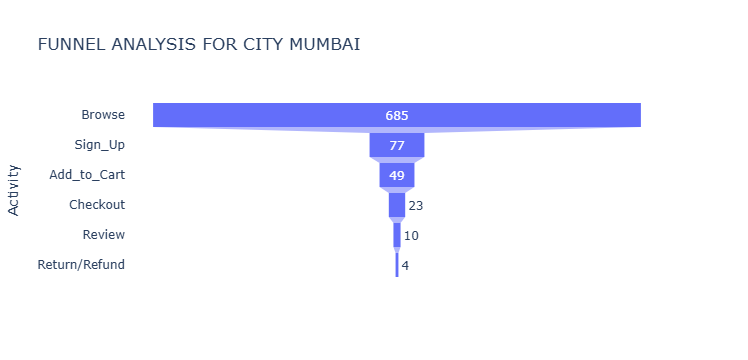

In [199]:
# Using function on a list of city 
cities = ['Chennai','Delhi','Kolkata','Noida','Mumbai']
for i in cities:
    city_funnel(i)

In [60]:
import plotly.io as pio
print(pio.templates)

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

